In [1]:
import os

from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/esameM"
os.chdir(path)
HOME = os.getcwd()
print(HOME)

Mounted at /content/drive
/content/drive/MyDrive/esameM


In [14]:
import os

input_dir = f'{HOME}/dataset/origForTrainingUnet/imageTest/'
target_dir = f'{HOME}/dataset/origForTrainingUnet/maskTest/'
img_size = (256, 256)
num_classes = 2
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 76
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/healthy10.jpg | /content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskTest/healthy10.png
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/healthy11.jpg | /content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskTest/healthy11.png
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/healthy12.jpg | /content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskTest/healthy12.png
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/healthy13.jpg | /content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskTest/healthy13.png
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/healthy14.jpg | /content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskTest/healthy14.png
/content/drive/MyDrive/esameM/dataset/origForTrainingUnet/imageTest/healthy15.jpg | /content/drive/MyDrive/esameM/dataset/origForTrainingUnet/maskTest/he

In [16]:

import numpy as np
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, target_img_path):
        global num_classes
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_jpeg(input_img, channels=3)
        input_img = tf_image.resize(input_img, img_size)
        input_img = tf_image.convert_image_dtype(input_img, "float32")


        target_img = tf_io.read_file(target_img_path)
        target_img = tf_io.decode_png(target_img, channels=1)
        target_img = tf_image.resize(target_img, img_size, method="nearest")
        target_img = tf_image.convert_image_dtype(target_img, "uint8")


        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        #target_img -= 1
        # commentato perchè già 0,1

        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)

In [6]:
import keras
modelPretrainedFile = f'{HOME}/model/betta_unet_segmentation.keras'
model = keras.models.load_model(modelPretrainedFile)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ activation[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 128, 128,  │      2,400 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 128, 128,  │      4,736 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 64, 64,    │      8,896 │ activation_3[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 6,168,520 (23.53 MB)

 Trainable params: 2,054,914 (7.84 MB)

 Non-trainable params: 3,776 (14.75 KB)

 Optimizer params: 4,109,830 (15.68 MB)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - loss: 0.2821
Model Performance Report:
Test Accuracy       : 0.9152
Test Dice Coefficient: 0.8116
Test IoU            : 0.7896
Test Loss           : 0.2821


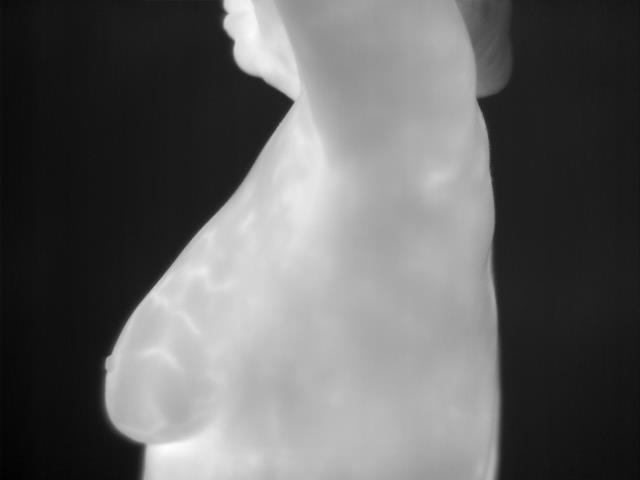

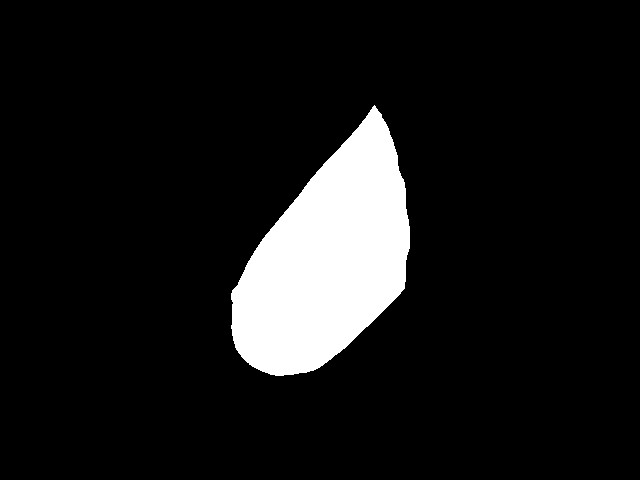

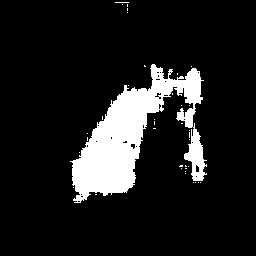

In [19]:
# Generate predictions for all images in the test set
from IPython.display import Image, display
from keras.utils import load_img
from PIL import ImageOps
import numpy as np
from keras.metrics import MeanIoU
import tensorflow as tf # Import tensorflow for dataset operations

test_dataset = get_dataset(
    batch_size, img_size, input_img_paths, target_img_paths
)
y_pred = model.predict(test_dataset)

# Correctly unpack the result of model.evaluate()
# It seems model.evaluate is only returning the loss, so we capture that.
test_loss = model.evaluate(test_dataset, verbose=1)

# Manually calculate accuracy, Dice, and IoU

# Extract true labels from the test_dataset
all_y_true = []
for _, labels in test_dataset:
    all_y_true.append(labels.numpy())
y_true = np.concatenate(all_y_true, axis=0)

# Remove the channel dimension if it's 1, to match y_pred_argmax shape
y_true_argmax = np.squeeze(y_true, axis=-1)

# Get predicted class masks
y_pred_argmax = np.argmax(y_pred, axis=-1)

# Calculate accuracy
test_accuracy = np.mean(y_pred_argmax == y_true_argmax)


# Calculate MeanIoU
m = MeanIoU(num_classes=num_classes)
m.update_state(y_true_argmax, y_pred_argmax)
test_iou = m.result().numpy()


# Calculate Dice Coefficient (F1 Score)
# Assuming binary segmentation where 0 is background and 1 is foreground
intersection = np.sum((y_pred_argmax == 1) & (y_true_argmax == 1))
union = np.sum((y_pred_argmax == 1) | (y_true_argmax == 1))
smooth = 1e-6 # To prevent division by zero in case of empty sets
test_dice = (2. * intersection + smooth) / (np.sum(y_pred_argmax == 1) + np.sum(y_true_argmax == 1) + smooth)

report = {
    "Test Accuracy": f"{test_accuracy:.4f}",
    "Test Dice Coefficient": f"{test_dice:.4f}",
    "Test IoU": f"{test_iou:.4f}",
    "Test Loss": f"{test_loss:.4f}"
}

# 7. Print formatted report
print("Model Performance Report:")
print("="*40)
for metric, value in report.items():
    print(f"{metric:20}: {value}")
print("="*40)


def display_mask(i):
    """Quick utility to display a model's prediction."""
    # Use y_pred for predictions
    mask = np.argmax(y_pred[i], axis=-1)
    mask = np.expand_dims(mask, axis=-1)
    img = ImageOps.autocontrast(keras.utils.array_to_img(mask))
    display(img)


# Display results for test image #10
i = 10

# Display input image
display(Image(filename=input_img_paths[i]))

# Display ground-truth target mask
img = ImageOps.autocontrast(load_img(target_img_paths[i]))
display(img)

# Display mask predicted by our model
display_mask(i)  # Note that the model only sees inputs at 150x150.
